# ThresholdPlot

`ThresholdPlot` evaluates a comfort model across a 2-D grid of input conditions and colours each region according to where the output falls. This makes it easy to see which combinations of inputs — temperature, humidity, air speed, clothing — land inside or outside a comfort zone, without manually running the model for every point.

In [1]:
import matplotlib.pyplot as plt

from pythermalcomfort.models import heat_index_rothfusz, pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import ThresholdPlot

## 1. Air Temperature vs Relative Humidity

The most common axis pairing for indoor comfort. At typical office conditions (sedentary activity, light clothing, still air), relative humidity plays a secondary role — the boundary between comfortable and warm shifts only slightly with humidity, which the chart makes immediately visible.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 3220 values [30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.1999

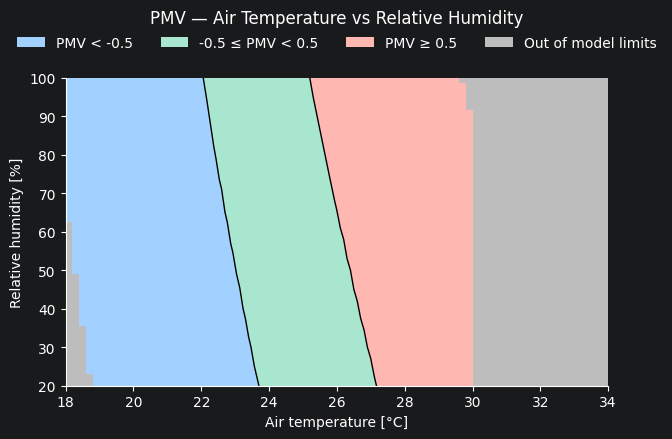

In [2]:
pmv_rh = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV — Air Temperature vs Relative Humidity")
)
pmv_rh.ax.set_xlabel("Air temperature [°C]")
pmv_rh.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 2. Air Temperature vs Air Speed

Air movement removes heat from the skin, which shifts the upper comfort boundary to the right as air speed increases. This plot is useful for ventilation design: it shows the minimum air speed needed to keep conditions comfortable at a given temperature. The mean radiant temperature is automatically linked to dry-bulb temperature (tr = tdb).

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 1220 values [30.19999999999997, 30.39999999999997, 30.59999999999997, 30.79999999999997, 30.999999999999968, 31.199999999999967, 31.399999999999967, 31.599999999999966, 31.799999999999965, 31.999999999999964, 32.19999999999996, 32.39999999999996, 32.599999999999966, 32.79999999999996, 32.99999999999996, 33.19999999999996, 33.39999999999996, 33.59999999999996, 33.799999999999955, 34.0, 30.19999999999997, 30.39999999999997, 30.59999999999997, 30.79999999999997, 30.999999999999968, 31.199999999999967, 31.399999999999967, 31.599999999999966, 31.799999999999965, 31.999999999999964, 32.19999999999996, 32.39999999999996, 32.599999999999966, 32.79999999999996, 32.99999999999996, 33.19999999999996, 33.39999999999996, 33.59999999999996, 33.799999999999955, 34.0, 30.19999999999997, 30.39999999999997, 30.59999999999997, 30.79999999999997, 30.999999999999968, 31.199999999999

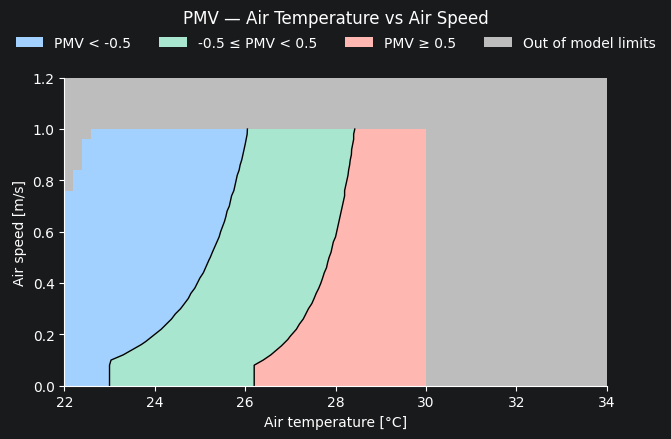

In [3]:
pmv_vr = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 22.0, 34.0, resolution=0.2)
    .set_y_axis("vr", 0.0, 1.2, resolution=0.02)
    .set_params(rh=50, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV — Air Temperature vs Air Speed")
)
pmv_vr.ax.set_xlabel("Air temperature [°C]")
pmv_vr.ax.set_ylabel("Air speed [m/s]")
plt.show()

## 3. Custom Labels and Colors

Pass `labels` and `colors` to `set_regions` to override the auto-generated region names and the default colour palette. The label list must have exactly `len(thresholds) + 1` entries.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 36 values [30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0, 30.5, 31.0, 31.5, 32.0] at indices [25, 26, 27, 28, 54, 55, 56, 57, 83, 84, 85, 86, 112, 113, 114, 115, 141, 142, 143, 144, 170, 171, 172, 173, 199, 200, 201, 202, 228, 229, 230, 231, 257, 258, 259, 260] outside the applicability limits [10.0, 30.0] and will be set to NaN.
  tdb_valid = valid_range(tdb, (10.0, 30.0))
/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:178: UserWarning: 'pmv' has 46 values [-2.5624472603942294, -2.409231512598652, -2.2556788891819037, -2.101786812497936, -2.5165078468254456, -2.361825801147301, -2.206766129218004, -2.051325299861875, -2.4705684332566626, -2.314420089695951, -2.15785336

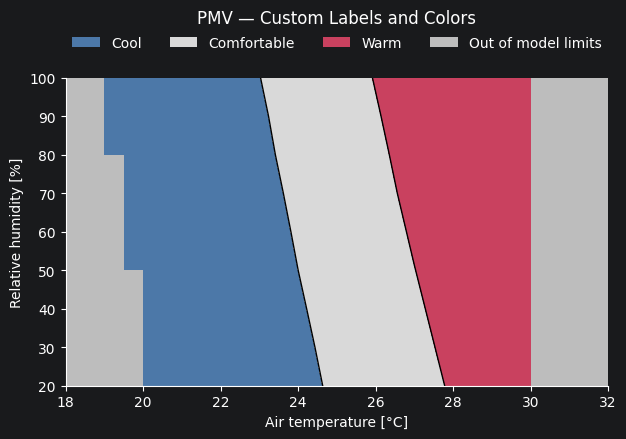

In [4]:
pmv_custom = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 32.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=10.0)
    .set_params(vr=0.20, met=1.2, clo=0.5, wme=0.0)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cool", "Comfortable", "Warm"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="PMV — Custom Labels and Colors")
)
pmv_custom.ax.set_xlabel("Air temperature [°C]")
pmv_custom.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 4. Styling Contour Lines, Fills, and the Legend

`line_kws`, `fill_kws`, and `legend_kws` are forwarded directly to `ax.plot`, `ax.contourf`, and `ax.legend`. Use them to match any figure style without subclassing or post-processing.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 3220 values [30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.1999

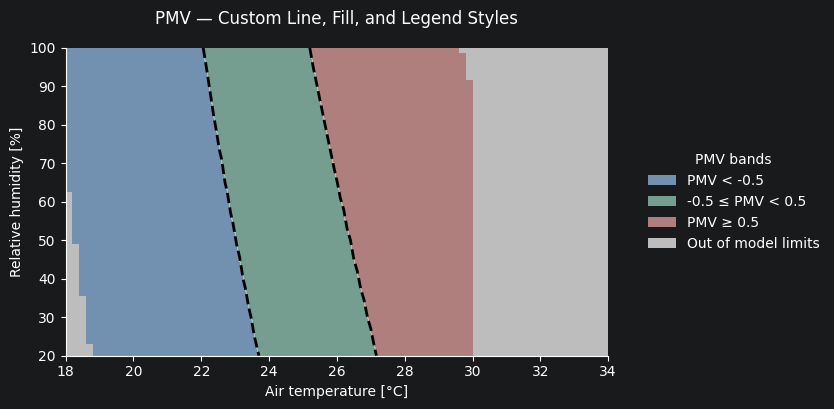

In [5]:
pmv_styled = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        line_kws={"color": "black", "linewidth": 2.0, "linestyle": "dashed"},
        fill_kws={"alpha": 0.65},
        legend_kws={
            "title": "PMV bands",
            "ncol": 1,
            "loc": "center left",
            "bbox_to_anchor": (1.05, 0.5),
        },
    )
)
pmv_styled.ax.set_title("PMV — Custom Line, Fill, and Legend Styles", y=1.05)
pmv_styled.ax.set_xlabel("Air temperature [°C]")
pmv_styled.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 5. Out-of-Model Areas

PMV ISO is only defined within a specific range of input conditions. Grid cells where the model returns `NaN` are shown in a separate colour and appear in the legend as 'Out of model limits'. Pass `invalid_color` to choose any Matplotlib-compatible colour.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 4020 values [30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 30.5, 31.0, 31.5, 32.

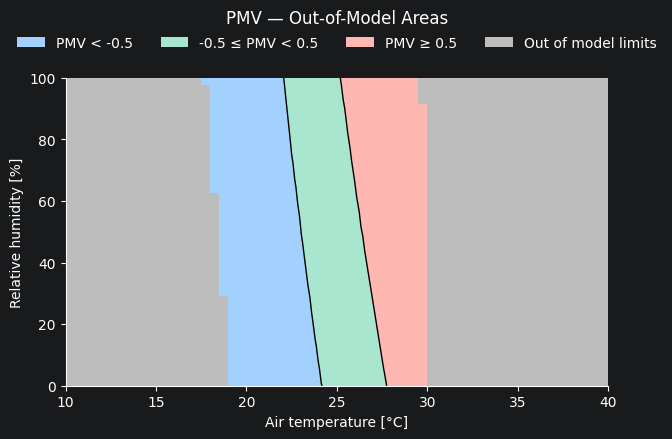

In [6]:
pmv_limits = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 10.0, 40.0, resolution=0.5)
    .set_y_axis("rh", 0.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV — Out-of-Model Areas", invalid_color="#bdbdbd")
)
pmv_limits.ax.set_xlabel("Air temperature [°C]")
pmv_limits.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 6. UTCI — Air Temperature vs Wind Speed

UTCI is designed for outdoor thermal environments where wind is a primary variable. Plotting air temperature against wind speed — at a fixed humidity and with mean radiant temperature linked to air temperature — shows how wind speed reduces heat stress in hot conditions. Region labels follow the official UTCI thermal stress scale.

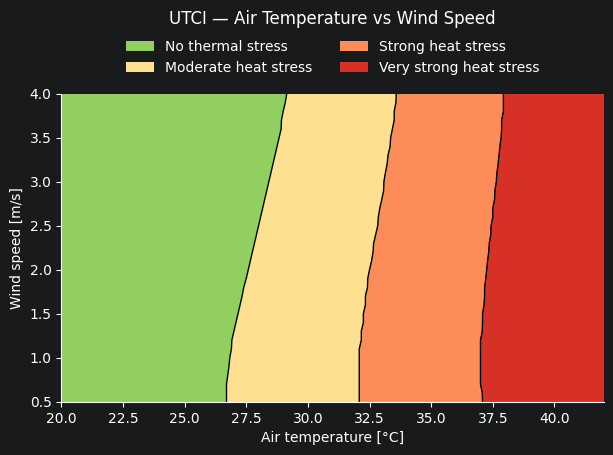

In [7]:
utci_result = (
    ThresholdPlot(utci)
    .set_x_axis("tdb", 20.0, 42.0, resolution=0.5)
    .set_y_axis("v", 0.5, 4.0, resolution=0.1)
    .set_params(rh=40)  # tr auto-linked to tdb
    .set_regions(
        output="utci",
        thresholds=[26, 32, 38],
        labels=[
            "No thermal stress",
            "Moderate heat stress",
            "Strong heat stress",
            "Very strong heat stress",
        ],
        colors=["#91cf60", "#fee090", "#fc8d59", "#d73027"],
    )
    .plot(legend_kws={"ncol": 2})
)
utci_result.ax.set_title("UTCI — Air Temperature vs Wind Speed", y=1.2)
utci_result.ax.set_xlabel("Air temperature [°C]")
utci_result.ax.set_ylabel("Wind speed [m/s]")
plt.show()

## 7. Heat Index

The Rothfusz heat index formula gives an apparent temperature at high humidity. The five regions follow the NWS risk scale. `show_lines=False` removes the boundary lines, which works well here because the filled regions are self-explanatory.

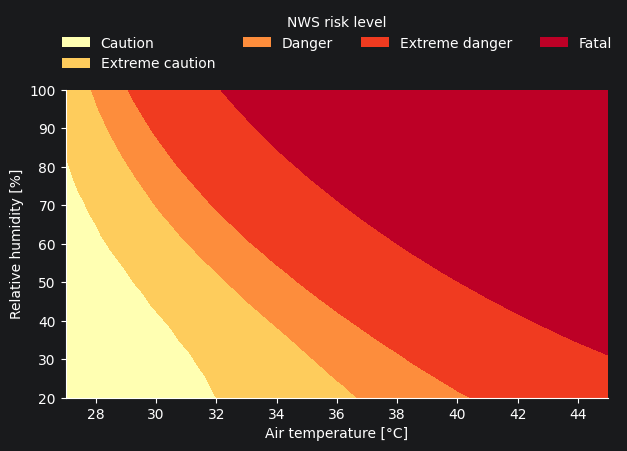

In [8]:
hi_result = (
    ThresholdPlot(heat_index_rothfusz)
    .set_x_axis("tdb", 27.0, 45.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=3.0)
    .set_regions(
        output="hi",
        thresholds=[30.0, 35.0, 40.0, 55.0],
        labels=["Caution", "Extreme caution", "Danger", "Extreme danger", "Fatal"],
        colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    )
    .plot(
        show_lines=False,
        legend_kws={"title": "NWS risk level"},
    )
)
hi_result.ax.set_xlabel("Air temperature [°C]")
hi_result.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 8. Legend, Boundary Lines, and Applicability Limits

`legend=False` and `show_lines=False` are rendering switches. `limit_inputs=False` is a model-level flag passed through `set_params` that disables the model's own applicability check — useful when you want to visualise conditions beyond the standard's defined range.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 3220 values [30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.1999

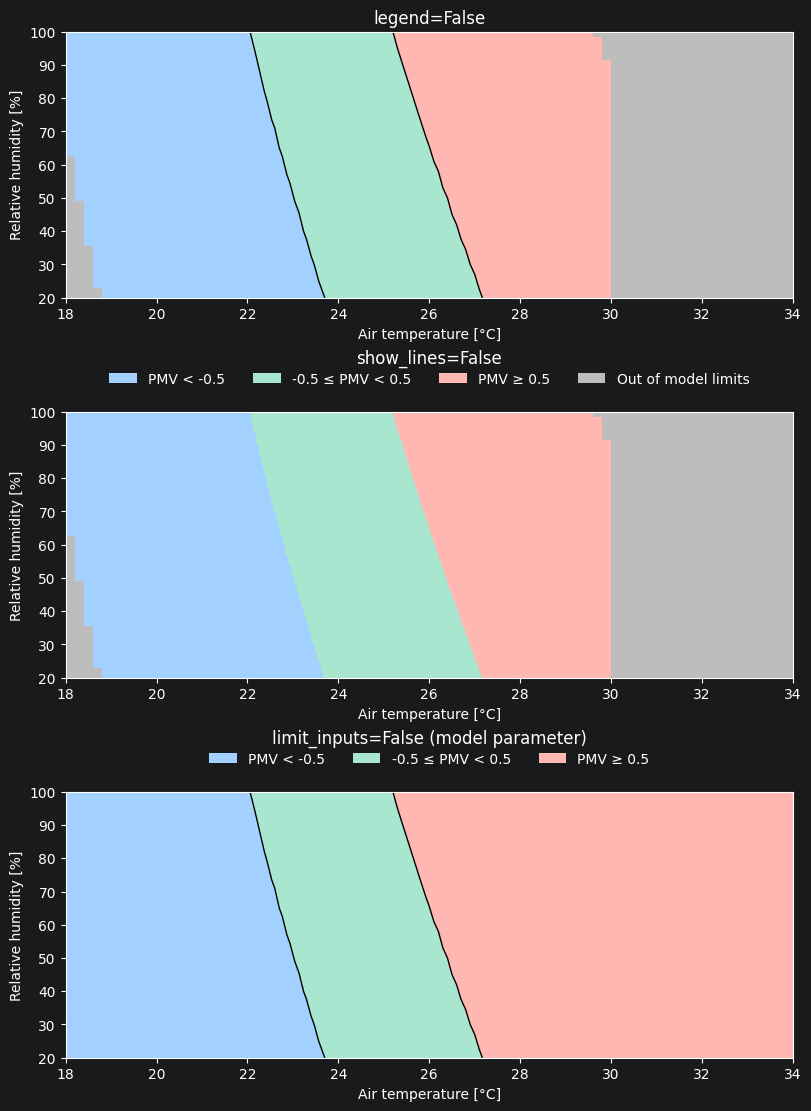

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8, 11), constrained_layout=True)

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=axes[0], title="legend=False", legend=False)
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=axes[1], title="show_lines=False", show_lines=False)
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0, limit_inputs=False)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=axes[2], title="limit_inputs=False (model parameter)")
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

plt.show()

## 9. The tr / tdb Parameter Link

When a model accepts both `tdb` and `tr` and you map only one of them to an axis, the other is automatically set to the same per-cell value (operative temperature assumption). Pass `tr=<value>` in `set_params` to override this and fix mean radiant temperature independently.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:178: UserWarning: 'pmv' has 13 values [-2.193193779814964, -2.042339972691313, -2.170224073030573, -2.0186371169656376, -2.1472543662461807, -2.124284659461789, -2.1013149526773973, -2.078345245893006, -2.0553755391086144, -2.032405832324223, -2.0094361255398314, 2.031897190312076, 2.0791501641682593] at indices [0, 1, 25, 26, 50, 75, 100, 125, 150, 175, 200, 399, 424] outside the applicability limits [-2, 2] and will be set to NaN.
  pmv_valid = valid_range(pmv, (-2, 2))
/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:178: UserWarning: 'pmv' has 2 values [2.031897190312076, 2.0791501641682593] at indices [399, 424] outside the applicability limits [-2, 2] and will be set to NaN.
  pmv_valid = valid_range(pmv, (-2, 2))


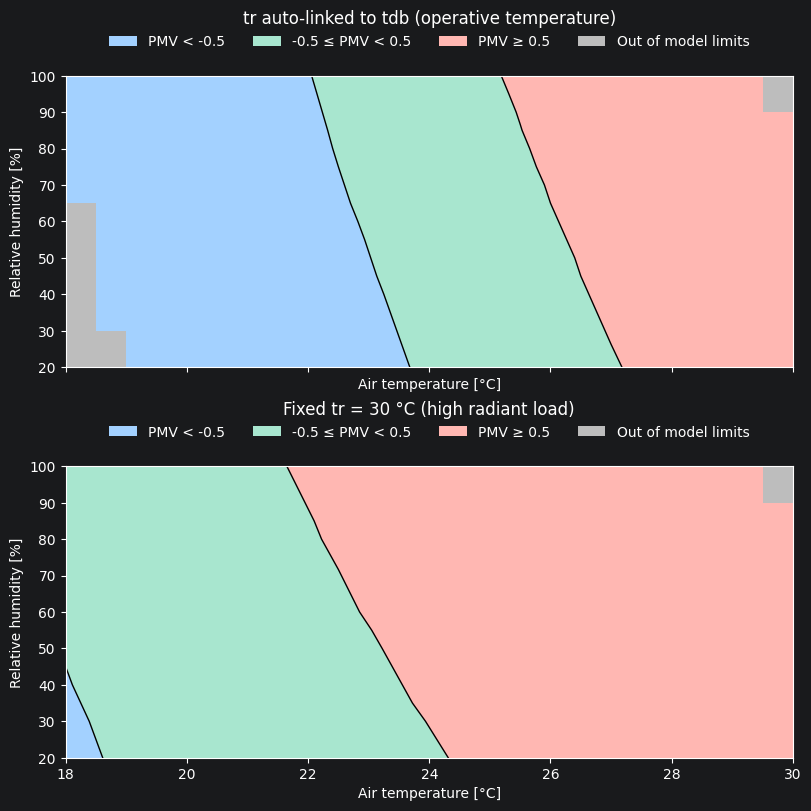

In [10]:
fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(8, 8), constrained_layout=True, sharex=True
)

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 30.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=5.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="tr auto-linked to tdb (operative temperature)")
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 30.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=5.0)
    .set_params(tr=30.0, vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax1, title="Fixed tr = 30 °C (high radiant load)")
).ax.set(xlabel="Air temperature [°C]", ylabel="Relative humidity [%]")

plt.show()

## 10. Modifying Returned Artists

`result.lines`, `result.fills`, and `result.legend` are ordinary Matplotlib artists. Modify them in place after calling `plot()` — useful for per-figure tweaks without restructuring the chain.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 328 values [30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0

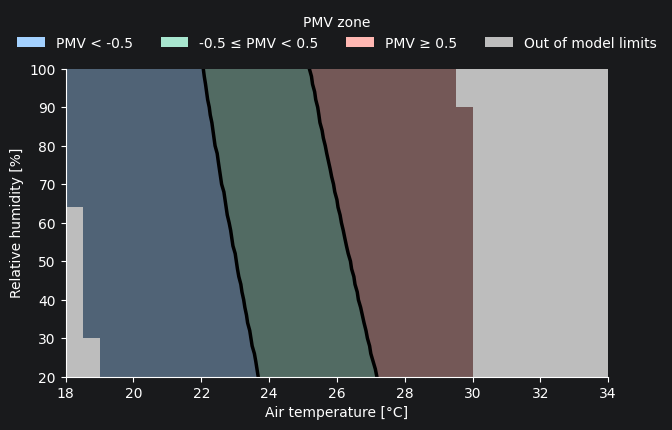

In [11]:
result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=2.0)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot()
)

# Thicken boundary lines
for line in result.lines:
    line.set_linewidth(2.5)

# Reduce fill opacity on the outer regions, keep the comfort zone solid
for fill, alpha in zip(result.fills, [0.4, 1.0, 0.4], strict=False):
    fill.set_alpha(alpha)

# Add a legend title
if result.legend:
    result.legend.set_title("PMV zone")

result.ax.set_xlabel("Air temperature [°C]")
result.ax.set_ylabel("Relative humidity [%]")
plt.show()

## 11. Using result.fig

`result.fig` is the underlying `Figure`. Use it for operations that span the whole figure — super-titles, saving to disk, multi-panel layouts.

/Users/ftar3919/Documents/github-projects/pythermalcomfort/pythermalcomfort/models/pmv_ppd_iso.py:173: UserWarning: 'tdb' has 3220 values [30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.199999999999953, 31.399999999999952, 31.59999999999995, 31.79999999999995, 31.99999999999995, 32.199999999999946, 32.39999999999995, 32.59999999999995, 32.79999999999995, 32.99999999999994, 33.199999999999946, 33.39999999999995, 33.599999999999945, 33.79999999999994, 34.0, 30.199999999999957, 30.399999999999956, 30.599999999999955, 30.799999999999955, 30.999999999999954, 31.1999

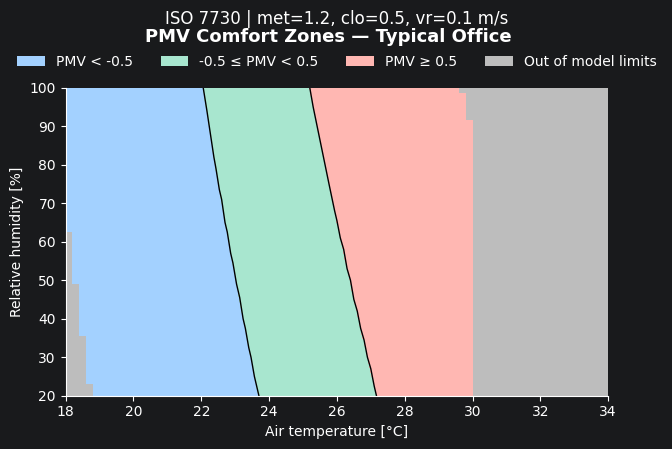

In [12]:
r = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot()
)

r.fig.suptitle(
    "PMV Comfort Zones — Typical Office", y=1.03, fontsize=13, fontweight="bold"
)
r.ax.set_title("ISO 7730 | met=1.2, clo=0.5, vr=0.1 m/s", y=1.18)
r.ax.set_xlabel("Air temperature [°C]")
r.ax.set_ylabel("Relative humidity [%]")

# r.fig.savefig("pmv_threshold.png", dpi=150, bbox_inches="tight")
plt.show()